Test the connection in the notebook

In [9]:
from dotenv import dotenv_values
from sqlalchemy import create_engine, text
from sqlalchemy.engine import make_url

config = dotenv_values(".env")
db_string = config["DB_STRING"]
print("Host:", make_url(db_string).host)

engine = create_engine(db_string)
with engine.connect() as conn:
    print(conn.execute(text("SELECT COUNT(*) FROM diabetes.patient")).scalar())

Host: ds-sql-playground.c8g8r1deus2v.eu-central-1.rds.amazonaws.com
768


In [10]:
import pandas as pd

SCHEMA = "diabetes"
patient          = pd.read_sql_table("patient",          engine, schema=SCHEMA)
blood_metrics    = pd.read_sql_table("blood_metrics",    engine, schema=SCHEMA)
pedigree_outcome = pd.read_sql_table("pedigree_outcome", engine, schema=SCHEMA)
skin             = pd.read_sql_table("skin",             engine, schema=SCHEMA)

In [11]:
import os
os.makedirs("data", exist_ok=True)

patient.to_csv("data/patient.csv", index=False)
blood_metrics.to_csv("data/blood_metrics.csv", index=False)
pedigree_outcome.to_csv("data/pedigree_outcome.csv", index=False)
skin.to_csv("data/skin.csv", index=False)

In [12]:
patient          = pd.read_csv("data/patient.csv")
blood_metrics    = pd.read_csv("data/blood_metrics.csv", parse_dates=["measurement_date"])
pedigree_outcome = pd.read_csv("data/pedigree_outcome.csv")
skin             = pd.read_csv("data/skin.csv")

In [13]:
patient.info()

<class 'pandas.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   id           768 non-null    int64  
 1   Age          768 non-null    int64  
 2   pregnancies  768 non-null    int64  
 3   bmi          768 non-null    float64
dtypes: float64(1), int64(3)
memory usage: 24.1 KB


In [14]:
blood_metrics.info()

<class 'pandas.DataFrame'>
RangeIndex: 1771 entries, 0 to 1770
Data columns (total 6 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   insulin           1771 non-null   int64         
 1   glucose           1771 non-null   int64         
 2   bloodpressure     1771 non-null   int64         
 3   patientid         1771 non-null   int64         
 4   id                1771 non-null   int64         
 5   measurement_date  1771 non-null   datetime64[us]
dtypes: datetime64[us](1), int64(5)
memory usage: 83.1 KB


In [15]:
import pandas as pd
from sqlalchemy import text

dataframes = {
    "patient": patient,
    "blood_metrics": blood_metrics,
    "pedigree_outcome": pedigree_outcome,
    "skin": skin,
}

def db_count(sql):
    with engine.connect() as conn:
        return conn.execute(text(sql)).scalar()

for table, df in dataframes.items():
    t = f'diabetes."{table}"'

    # Rows and columns
    db_rows = db_count(f"SELECT COUNT(*) FROM {t}")
    db_cols = db_count(f"""SELECT COUNT(*) FROM information_schema.columns
                           WHERE table_schema='diabetes' AND table_name='{table}'""")
    print(f"\n===== {table} =====")
    print(f"Rows:    db = {db_rows}   notebook = {df.shape[0]}")
    print(f"Columns: db = {db_cols}   notebook = {df.shape[1]}")

    # NULL/NaN and zeros per column
    rows = []
    for col in df.columns:
        db_null = db_count(f'SELECT COUNT(*) FROM {t} WHERE "{col}" IS NULL')
        nb_null = df[col].isna().sum()

        if pd.api.types.is_numeric_dtype(df[col]):
            db_zero = db_count(f'SELECT COUNT(*) FROM {t} WHERE "{col}" = 0')
            nb_zero = (df[col] == 0).sum()
        else:
            db_zero = nb_zero = "-"   # e.g. the date column

        rows.append([col, db_null, nb_null, db_zero, nb_zero])

    print(pd.DataFrame(rows, columns=["column", "null_db", "null_nb", "zero_db", "zero_nb"])
          .to_string(index=False))


===== patient =====
Rows:    db = 768   notebook = 768
Columns: db = 4   notebook = 4
     column  null_db  null_nb  zero_db  zero_nb
         id        0        0        0        0
        Age        0        0        0        0
pregnancies        0        0      111      111
        bmi        0        0       11       11

===== blood_metrics =====
Rows:    db = 1771   notebook = 1771
Columns: db = 6   notebook = 6
          column  null_db  null_nb zero_db zero_nb
         insulin        0        0     380     380
         glucose        0        0       9       9
   bloodpressure        0        0      36      36
       patientid        0        0       0       0
              id        0        0       0       0
measurement_date        0        0       -       -

===== pedigree_outcome =====
Rows:    db = 768   notebook = 768
Columns: db = 4   notebook = 4
                  column  null_db  null_nb  zero_db  zero_nb
diabetespedigreefunction        0        0        0        0
   

In [16]:
# Patient numbers in each table (without changing the data)
keys = {
    "patient":          patient["id"],
    "blood_metrics":    blood_metrics["patientid"],
    "pedigree_outcome": pedigree_outcome["patientid"],
    "skin":             skin["patientid"],
}

# 1. Overview: rows, different patients, empty IDs, repeated IDs
overview = pd.DataFrame({
    name: {
        "rows":             len(k),
        "unique_patients":  k.nunique(),
        "missing_id (NaN)": k.isna().sum(),
        "repeated_ids":     k.duplicated().sum(),
    }
    for name, k in keys.items()
}).T
print(overview, "\n")

# 2. Compare every table with the patient table
patient_ids = set(patient["id"])
for name, k in keys.items():
    if name == "patient":
        continue
    ids = set(k.dropna())
    not_in_table   = patient_ids - ids   # patients with no row in this table
    not_in_patient = ids - patient_ids   # IDs that don't exist in patient
    print(f"{name}:")
    print(f"  patients missing in this table: {len(not_in_table)}  {sorted(not_in_table)[:10]}")
    print(f"  unknown IDs (not in patient):   {len(not_in_patient)}  {sorted(not_in_patient)[:10]}")

                  rows  unique_patients  missing_id (NaN)  repeated_ids
patient            768              768                 0             0
blood_metrics     1771             1003                 0           768
pedigree_outcome   768              768                 0             0
skin               768              768                 0             0 

blood_metrics:
  patients missing in this table: 0  []
  unknown IDs (not in patient):   235  [1000, 1001, 1002, 1003, 1004, 1005, 1006, 1007, 1008, 1009]
pedigree_outcome:
  patients missing in this table: 0  []
  unknown IDs (not in patient):   0  []
skin:
  patients missing in this table: 0  []
  unknown IDs (not in patient):   0  []


In [17]:
bm = blood_metrics

# How often does each patient ID appear?
counts = bm["patientid"].value_counts()

print("Patient IDs that appear only once:", (counts == 1).sum())
print("Patient IDs that appear more than once:", (counts > 1).sum())
print("Rows belonging to IDs that appear once:", bm["patientid"].isin(counts[counts == 1].index).sum())
print("Rows belonging to IDs that appear more than once:", bm["patientid"].isin(counts[counts > 1].index).sum())

# Only the patients with several rows
rep = bm[bm["patientid"].isin(counts[counts > 1].index)]

# For each column: how many of these patients have DIFFERENT values in their rows?
cols = ["measurement_date", "insulin", "glucose", "bloodpressure"]
print("\nPatients whose rows differ in this column:")
print(rep.groupby("patientid")[cols].nunique(dropna=False).gt(1).sum())

# Are the rows completely identical (all columns except id)?
identical = rep.duplicated(subset=["patientid"] + cols, keep=False)
print("\nRows fully identical to another row of the same patient:", identical.sum())
print("Rows that differ in at least one column:", (~identical).sum())

Patient IDs that appear only once: 235
Patient IDs that appear more than once: 768
Rows belonging to IDs that appear once: 235
Rows belonging to IDs that appear more than once: 1536

Patients whose rows differ in this column:
measurement_date    768
insulin             763
glucose             764
bloodpressure       761
dtype: int64

Rows fully identical to another row of the same patient: 0
Rows that differ in at least one column: 1536


In [19]:
# The 235 IDs that appear only in blood_metrics
unknown_ids = set(blood_metrics["patientid"]) - set(patient["id"])
print("Unknown IDs:", len(unknown_ids), "\n")

# Patient number column in each table
tables = {
    "patient":          patient["id"],
    "pedigree_outcome": pedigree_outcome["patientid"],
    "skin":             skin["patientid"],
    "blood_metrics":    blood_metrics["patientid"],
}

for name, ids in tables.items():
    found = unknown_ids & set(ids)
    print(f"{name:17} → found {len(found):3} of {len(unknown_ids)}")

Unknown IDs: 235 

patient           → found   0 of 235
pedigree_outcome  → found   0 of 235
skin              → found   0 of 235
blood_metrics     → found 235 of 235


In [18]:
# The 235 IDs that appear only in blood_metrics
unknown_ids = set(blood_metrics["patientid"]) - set(patient["id"])
print("Unknown IDs in blood_metrics:", len(unknown_ids))

# Do any of them exist in the outcome table?
in_outcome = unknown_ids & set(pedigree_outcome["patientid"])
print("Of these, found in pedigree_outcome:", len(in_outcome))

# For comparison: the 768 real patients
real_ids = set(patient["id"])
print("Real patients found in pedigree_outcome:",
      len(real_ids & set(pedigree_outcome["patientid"])))

Unknown IDs in blood_metrics: 235
Of these, found in pedigree_outcome: 0
Real patients found in pedigree_outcome: 768


In [20]:
# New table: only patients that exist in the patient table
blood_metrics_clean = blood_metrics[blood_metrics["patientid"].isin(patient["id"])].copy()

# Check
print("Original:", blood_metrics.shape)          # (1771, 6) → unchanged
print("Clean:   ", blood_metrics_clean.shape)    # (1536, 6)
print("Patients in clean:", blood_metrics_clean["patientid"].nunique())   # 768
print("Rows per patient:", blood_metrics_clean.groupby("patientid").size().unique())  # [2]

Original: (1771, 6)
Clean:    (1536, 6)
Patients in clean: 768
Rows per patient: [2]


In [21]:
blood_metrics_unknown = blood_metrics[~blood_metrics["patientid"].isin(patient["id"])].copy()
print("Unknown:", blood_metrics_unknown.shape)   # (235, 6)

Unknown: (235, 6)


In [ ]:
# Backup of the long version (1536 rows, 2 per patient)
blood_metrics_clean_long = blood_metrics_clean.copy()

# 1. Sort by date and number each test: 1 = earlier, 2 = later
bm = blood_metrics_clean_long.sort_values(["patientid", "measurement_date"]).copy()
bm["test_nr"] = bm.groupby("patientid").cumcount() + 1

# 2. Pivot: one row per patient, each whole test moves together
blood_metrics_clean = bm.pivot(index="patientid",
                               columns="test_nr",
                               values=["measurement_date", "insulin", "glucose", "bloodpressure"])

# 3. Column names: ('insulin', 1) → 'insulin_1'
blood_metrics_clean.columns = [f"{col}_{nr}" for col, nr in blood_metrics_clean.columns]
blood_metrics_clean = blood_metrics_clean.reset_index()

# 4. Checks
print("Shape:", blood_metrics_clean.shape)                                  # (768, 9)
print("One row per patient:", blood_metrics_clean["patientid"].is_unique)  # True
print("Empty cells:", blood_metrics_clean.isna().sum().sum())              # 0
print("Date 1 always before date 2:",
      (blood_metrics_clean["measurement_date_1"] < blood_metrics_clean["measurement_date_2"]).all())

check = bm.merge(blood_metrics_clean, on="patientid")
for m in ["measurement_date", "insulin", "glucose", "bloodpressure"]:
    t1 = (check.loc[check["test_nr"] == 1, m] == check.loc[check["test_nr"] == 1, f"{m}_1"]).all()
    t2 = (check.loc[check["test_nr"] == 2, m] == check.loc[check["test_nr"] == 2, f"{m}_2"]).all()
    print(f"{m:17} test 1 correct: {t1}   test 2 correct: {t2}")

# 5. Save
blood_metrics_clean.to_csv("data/blood_metrics_clean.csv", index=False)
blood_metrics_clean.head()

In [22]:
# 1. Sort by date and number each test: 1 = earlier, 2 = later
blood_metrics_sorted = blood_metrics_clean.sort_values(["patientid", "measurement_date"]).copy()
blood_metrics_sorted["test_nr"] = blood_metrics_sorted.groupby("patientid").cumcount() + 1

# 2. Pivot: one row per patient, each whole test moves together
blood_metrics_wide = blood_metrics_sorted.pivot(
    index="patientid",
    columns="test_nr",
    values=["measurement_date", "insulin", "glucose", "bloodpressure"],
)
blood_metrics_wide.columns = [f"{col}_{nr}" for col, nr in blood_metrics_wide.columns]
blood_metrics_wide = blood_metrics_wide.reset_index()

# 3. Checks
print("Shape:", blood_metrics_wide.shape)                                   # (768, 9)
print("One row per patient:", blood_metrics_wide["patientid"].is_unique)   # True
print("Empty cells:", blood_metrics_wide.isna().sum().sum())               # 0
print("Date 1 before date 2:",
      (blood_metrics_wide["measurement_date_1"] < blood_metrics_wide["measurement_date_2"]).all())

wide_check = blood_metrics_sorted.merge(blood_metrics_wide, on="patientid")
for metric in ["measurement_date", "insulin", "glucose", "bloodpressure"]:
    rows_test1 = wide_check[wide_check["test_nr"] == 1]
    rows_test2 = wide_check[wide_check["test_nr"] == 2]
    ok1 = (rows_test1[metric] == rows_test1[f"{metric}_1"]).all()
    ok2 = (rows_test2[metric] == rows_test2[f"{metric}_2"]).all()
    print(f"{metric:17} test 1 correct: {ok1}   test 2 correct: {ok2}")

# 4. Save
blood_metrics_clean.to_csv("data/blood_metrics_clean.csv", index=False)
blood_metrics_unknown.to_csv("data/blood_metrics_unknown.csv", index=False)
blood_metrics_wide.to_csv("data/blood_metrics_wide.csv", index=False)
blood_metrics_wide.head()

Shape: (768, 9)
One row per patient: True
Empty cells: 0
Date 1 before date 2: True
measurement_date  test 1 correct: True   test 2 correct: True
insulin           test 1 correct: True   test 2 correct: True
glucose           test 1 correct: True   test 2 correct: True
bloodpressure     test 1 correct: True   test 2 correct: True


,patientid,measurement_date_1,measurement_date_2,insulin_1,insulin_2,glucose_1,glucose_2,bloodpressure_1,bloodpressure_2
0,1,2022-12-01,2022-12-13,80,0,172,148,117,72
1,2,2022-12-01,2022-12-13,80,0,54,85,93,66
2,3,2022-12-01,2022-12-13,1,0,168,183,100,64
3,4,2022-12-01,2022-12-13,26,94,53,89,39,66
4,5,2022-12-01,2022-12-13,54,168,184,137,116,40


# extra check ...

In [23]:
# Turn the wide table back into rows: one row per patient and test
wide_as_rows = pd.concat([
    blood_metrics_wide[["patientid", f"measurement_date_{n}", f"insulin_{n}",
                        f"glucose_{n}", f"bloodpressure_{n}"]]
    .rename(columns={f"measurement_date_{n}": "measurement_date",
                     f"insulin_{n}": "insulin",
                     f"glucose_{n}": "glucose",
                     f"bloodpressure_{n}": "bloodpressure"})
    .assign(test_nr=n)
    for n in (1, 2)
])

# Find each test in the ORIGINAL table by patient + date
original_vs_wide = wide_as_rows.merge(
    blood_metrics,
    on=["patientid", "measurement_date"],
    how="left",
    suffixes=("_wide", "_original"),
    indicator=True,
)

# Checks
print("Tests in wide table:", len(wide_as_rows))                       # 1536
print("Found in original:  ", (original_vs_wide["_merge"] == "both").sum())  # 1536
print("Not found:          ", (original_vs_wide["_merge"] == "left_only").sum())  # 0
print("Rows after merge:   ", len(original_vs_wide))                  # 1536 (no double matches)

print()
for test in (1, 2):
    rows_of_test = original_vs_wide[original_vs_wide["test_nr"] == test]
    for metric in ["insulin", "glucose", "bloodpressure"]:
        same = (rows_of_test[f"{metric}_wide"] == rows_of_test[f"{metric}_original"]).all()
        print(f"Date {test}  {metric:14} same as original: {same}")

Tests in wide table: 1536
Found in original:   1536
Not found:           0
Rows after merge:    1536

Date 1  insulin        same as original: True
Date 1  glucose        same as original: True
Date 1  bloodpressure  same as original: True
Date 2  insulin        same as original: True
Date 2  glucose        same as original: True
Date 2  bloodpressure  same as original: True


In [24]:
blood_metrics_wide.head()

,patientid,measurement_date_1,measurement_date_2,insulin_1,insulin_2,glucose_1,glucose_2,bloodpressure_1,bloodpressure_2
0,1,2022-12-01,2022-12-13,80,0,172,148,117,72
1,2,2022-12-01,2022-12-13,80,0,54,85,93,66
2,3,2022-12-01,2022-12-13,1,0,168,183,100,64
3,4,2022-12-01,2022-12-13,26,94,53,89,39,66
4,5,2022-12-01,2022-12-13,54,168,184,137,116,40


In [25]:
blood_metrics_wide.info()

<class 'pandas.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   patientid           768 non-null    int64         
 1   measurement_date_1  768 non-null    datetime64[us]
 2   measurement_date_2  768 non-null    datetime64[us]
 3   insulin_1           768 non-null    object        
 4   insulin_2           768 non-null    object        
 5   glucose_1           768 non-null    object        
 6   glucose_2           768 non-null    object        
 7   bloodpressure_1     768 non-null    object        
 8   bloodpressure_2     768 non-null    object        
dtypes: datetime64[us](2), int64(1), object(6)
memory usage: 54.1+ KB


In [26]:
for metric in ["insulin", "glucose", "bloodpressure"]:
    original_sum = blood_metrics_clean[metric].sum()
    wide_sum = blood_metrics_wide[f"{metric}_1"].sum() + blood_metrics_wide[f"{metric}_2"].sum()
    print(f"{metric:14} original: {original_sum}   wide: {wide_sum}   same: {original_sum == wide_sum}")

insulin        original: 98464   wide: 98464   same: True
glucose        original: 171185   wide: 171185   same: True
bloodpressure  original: 101495   wide: 101495   same: True


In [27]:
tables_to_combine = {
    "patient":            (patient,            "id"),
    "blood_metrics_wide": (blood_metrics_wide, "patientid"),
    "skin":               (skin,               "patientid"),
    "pedigree_outcome":   (pedigree_outcome,   "patientid"),
}

# 1. Info of every table
for combine_name, (combine_df, combine_key) in tables_to_combine.items():
    print(f"\n========== {combine_name} ==========")
    combine_df.info()

# 2. Key overview
reference_ids = set(patient["id"])
key_check_rows = []
for combine_name, (combine_df, combine_key) in tables_to_combine.items():
    key_values = combine_df[combine_key]
    key_check_rows.append({
        "table":              combine_name,
        "key_column":         combine_key,
        "dtype":              str(key_values.dtype),
        "rows":               len(combine_df),
        "unique_keys":        key_values.nunique(),
        "missing_keys":       key_values.isna().sum(),
        "same_ids_as_patient": set(key_values) == reference_ids,
    })

print("\n========== KEY CHECK ==========")
print(pd.DataFrame(key_check_rows).to_string(index=False))


========== patient ==========
<class 'pandas.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   id           768 non-null    int64  
 1   Age          768 non-null    int64  
 2   pregnancies  768 non-null    int64  
 3   bmi          768 non-null    float64
dtypes: float64(1), int64(3)
memory usage: 24.1 KB

========== blood_metrics_wide ==========
<class 'pandas.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   patientid           768 non-null    int64         
 1   measurement_date_1  768 non-null    datetime64[us]
 2   measurement_date_2  768 non-null    datetime64[us]
 3   insulin_1           768 non-null    object        
 4   insulin_2           768 non-null    object        
 5   glucose_1           768 non-null    objec

In [28]:
skin_clean             = skin.drop(columns="id").copy()
pedigree_outcome_clean = pedigree_outcome.drop(columns="id").copy()

print("skin:            ", skin.shape, "→", skin_clean.shape)                          # (768, 3) → (768, 2)
print("pedigree_outcome:", pedigree_outcome.shape, "→", pedigree_outcome_clean.shape)  # (768, 4) → (768, 3)
print(skin_clean.columns.tolist())              # ['skinthickness', 'patientid']
print(pedigree_outcome_clean.columns.tolist())  # ['diabetespedigreefunction', 'outcome', 'patientid']

# Save
skin_clean.to_csv("data/skin_clean.csv", index=False)
pedigree_outcome_clean.to_csv("data/pedigree_outcome_clean.csv", index=False)

skin:             (768, 3) → (768, 2)
pedigree_outcome: (768, 4) → (768, 3)
['skinthickness', 'patientid']
['diabetespedigreefunction', 'outcome', 'patientid']


# check data types

In [29]:
tables_before_combine = {
    "patient":                patient,
    "blood_metrics_wide":     blood_metrics_wide,
    "skin_clean":             skin_clean,
    "pedigree_outcome_clean": pedigree_outcome_clean,
}

column_check_rows = []
for check_table, check_df in tables_before_combine.items():
    for check_col in check_df.columns:
        col_values = check_df[check_col]
        is_number = pd.api.types.is_numeric_dtype(col_values)
        column_check_rows.append({
            "table":   check_table,
            "column":  check_col,
            "dtype":   str(col_values.dtype),
            "rows":    len(col_values),
            "empty":   col_values.isna().sum(),
            "zeros":   (col_values == 0).sum() if is_number else "-",
            "unique":  col_values.nunique(),
            "min":     col_values.min(),
            "max":     col_values.max(),
            "type_ok": col_values.dtype != "object",
        })

column_check = pd.DataFrame(column_check_rows)
pd.set_option("display.max_rows", None)
display(column_check)

print("Columns with wrong type (object):")
print(column_check.loc[~column_check["type_ok"], ["table", "column"]].to_string(index=False)
      if (~column_check["type_ok"]).any() else "none ✓")

,table,column,dtype,rows,empty,zeros,unique,min,max,type_ok
0,patient,id,int64,768,0,0,768,1,768,True
1,patient,Age,int64,768,0,0,52,21,81,True
2,patient,pregnancies,int64,768,0,111,17,0,17,True
3,patient,bmi,float64,768,0,11,248,0.0,67.1,True
4,blood_metrics_wide,patientid,int64,768,0,0,768,1,768,True
5,blood_metrics_wide,measurement_date_1,datetime64[us],768,0,-,1,2022-12-01 00:00:00,2022-12-01 00:00:00,True
6,blood_metrics_wide,measurement_date_2,datetime64[us],768,0,-,1,2022-12-13 00:00:00,2022-12-13 00:00:00,True
7,blood_metrics_wide,insulin_1,object,768,0,-,101,0,100,False
8,blood_metrics_wide,insulin_2,object,768,0,-,186,0,846,False
9,blood_metrics_wide,glucose_1,object,768,0,-,196,0,200,False


Columns with wrong type (object):
             table          column
blood_metrics_wide       insulin_1
blood_metrics_wide       insulin_2
blood_metrics_wide       glucose_1
blood_metrics_wide       glucose_2
blood_metrics_wide bloodpressure_1
blood_metrics_wide bloodpressure_2


In [30]:
# 1. Fix the types in blood_metrics_wide
metric_cols = ["insulin_1", "insulin_2", "glucose_1", "glucose_2",
               "bloodpressure_1", "bloodpressure_2"]
blood_metrics_wide[metric_cols] = blood_metrics_wide[metric_cols].astype("int64")

# 2. Combine: patient.id ↔ patientid in the other tables
diabetes_combined = (
    patient
    .merge(blood_metrics_wide,     left_on="id", right_on="patientid", how="left", validate="one_to_one")
    .merge(skin_clean,             on="patientid", how="left", validate="one_to_one")
    .merge(pedigree_outcome_clean, on="patientid", how="left", validate="one_to_one")
    .drop(columns="id")
)
diabetes_combined = diabetes_combined[
    ["patientid"]
    + [c for c in diabetes_combined.columns if c not in ("patientid", "outcome")]
    + ["outcome"]
]

# 3. Checks
print("Shape:", diabetes_combined.shape)                                  # (768, 15)
print("One row per patient:", diabetes_combined["patientid"].is_unique)  # True
print("Empty cells:", diabetes_combined.isna().sum().sum())              # 0
print("Object columns:", diabetes_combined.select_dtypes("object").columns.tolist())  # []
print(diabetes_combined["outcome"].value_counts())                        # 0: 500, 1: 268

# 4. Save
diabetes_combined.to_csv("data/diabetes_combined.csv", index=False)
diabetes_combined.head()

Shape: (768, 15)
One row per patient: True
Empty cells: 0
Object columns: []
outcome
0    500
1    268
Name: count, dtype: int64


,patientid,Age,pregnancies,bmi,measurement_date_1,measurement_date_2,insulin_1,insulin_2,glucose_1,glucose_2,bloodpressure_1,bloodpressure_2,skinthickness,diabetespedigreefunction,outcome
0,1,50,6,33.6,2022-12-01,2022-12-13,80,0,172,148,117,72,35,0.627,1
1,2,31,1,26.6,2022-12-01,2022-12-13,80,0,54,85,93,66,29,0.351,0
2,3,32,8,23.3,2022-12-01,2022-12-13,1,0,168,183,100,64,0,0.672,1
3,4,21,1,28.1,2022-12-01,2022-12-13,26,94,53,89,39,66,23,0.167,0
4,5,33,0,43.1,2022-12-01,2022-12-13,54,168,184,137,116,40,35,2.288,1


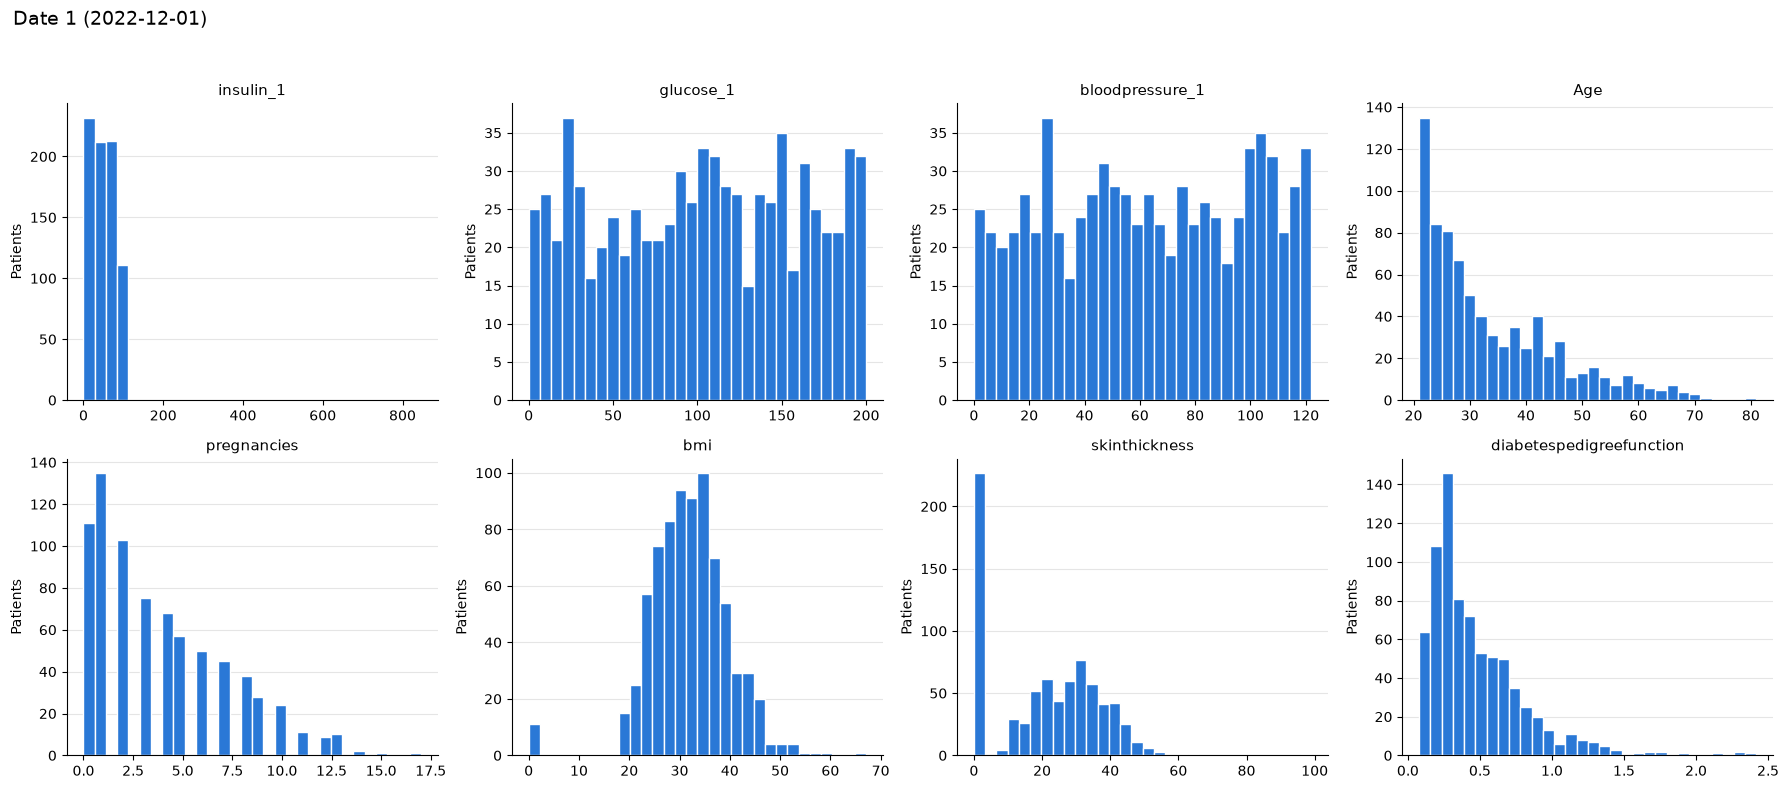

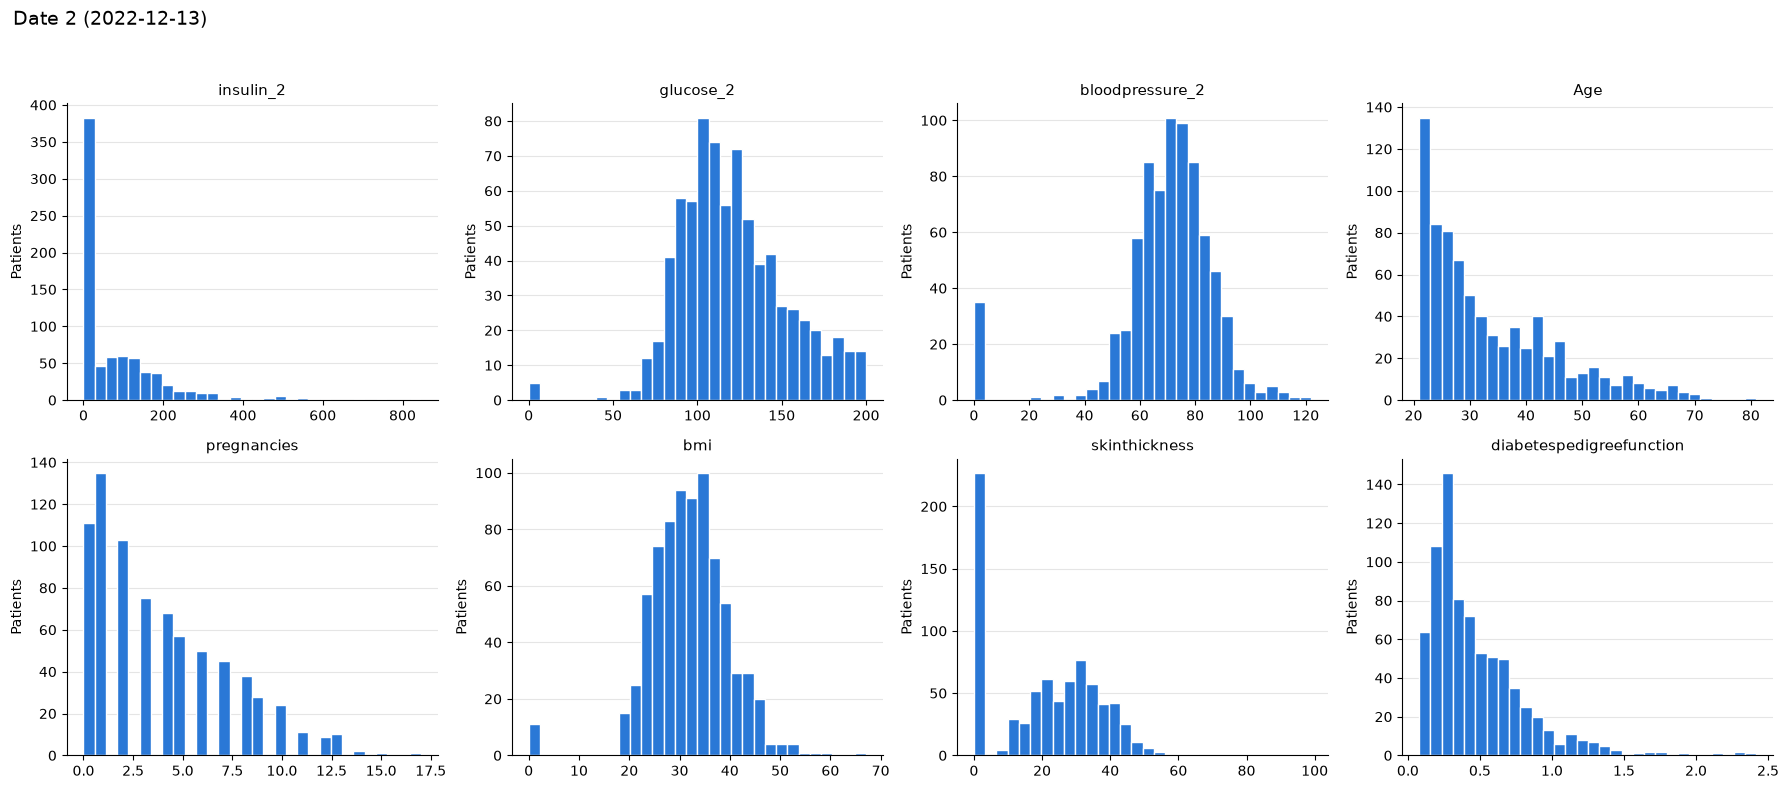

In [32]:
import matplotlib.pyplot as plt

date1_cols = ["insulin_1", "glucose_1", "bloodpressure_1",
              "Age", "pregnancies", "bmi", "skinthickness", "diabetespedigreefunction"]
date2_cols = ["insulin_2", "glucose_2", "bloodpressure_2",
              "Age", "pregnancies", "bmi", "skinthickness", "diabetespedigreefunction"]

# Same x-axis range for test 1 and test 2, so the two figures are comparable
shared_range = {m: (min(diabetes_combined[f"{m}_1"].min(), diabetes_combined[f"{m}_2"].min()),
                    max(diabetes_combined[f"{m}_1"].max(), diabetes_combined[f"{m}_2"].max()))
                for m in ["insulin", "glucose", "bloodpressure"]}

def plot_date(date_cols, date_title):
    fig, axes = plt.subplots(2, 4, figsize=(18, 8))
    for ax, plot_col in zip(axes.flat, date_cols):
        metric = plot_col.rsplit("_", 1)[0]
        value_range = shared_range.get(metric)          # only for the 3 blood metrics
        ax.hist(diabetes_combined[plot_col], bins=30, range=value_range,
                color="#2a78d6", edgecolor="white", linewidth=1)
        ax.set_title(plot_col, fontsize=11)
        ax.set_ylabel("Patients")
        ax.grid(axis="y", color="#e5e5e5", linewidth=0.8)
        ax.set_axisbelow(True)
        ax.spines[["top", "right"]].set_visible(False)
    fig.suptitle(date_title, fontsize=14, x=0.01, ha="left")
    fig.tight_layout(rect=(0, 0, 1, 0.95))
    plt.show()

plot_date(date1_cols, "Date 1 (2022-12-01)")
plot_date(date2_cols, "Date 2 (2022-12-13)")

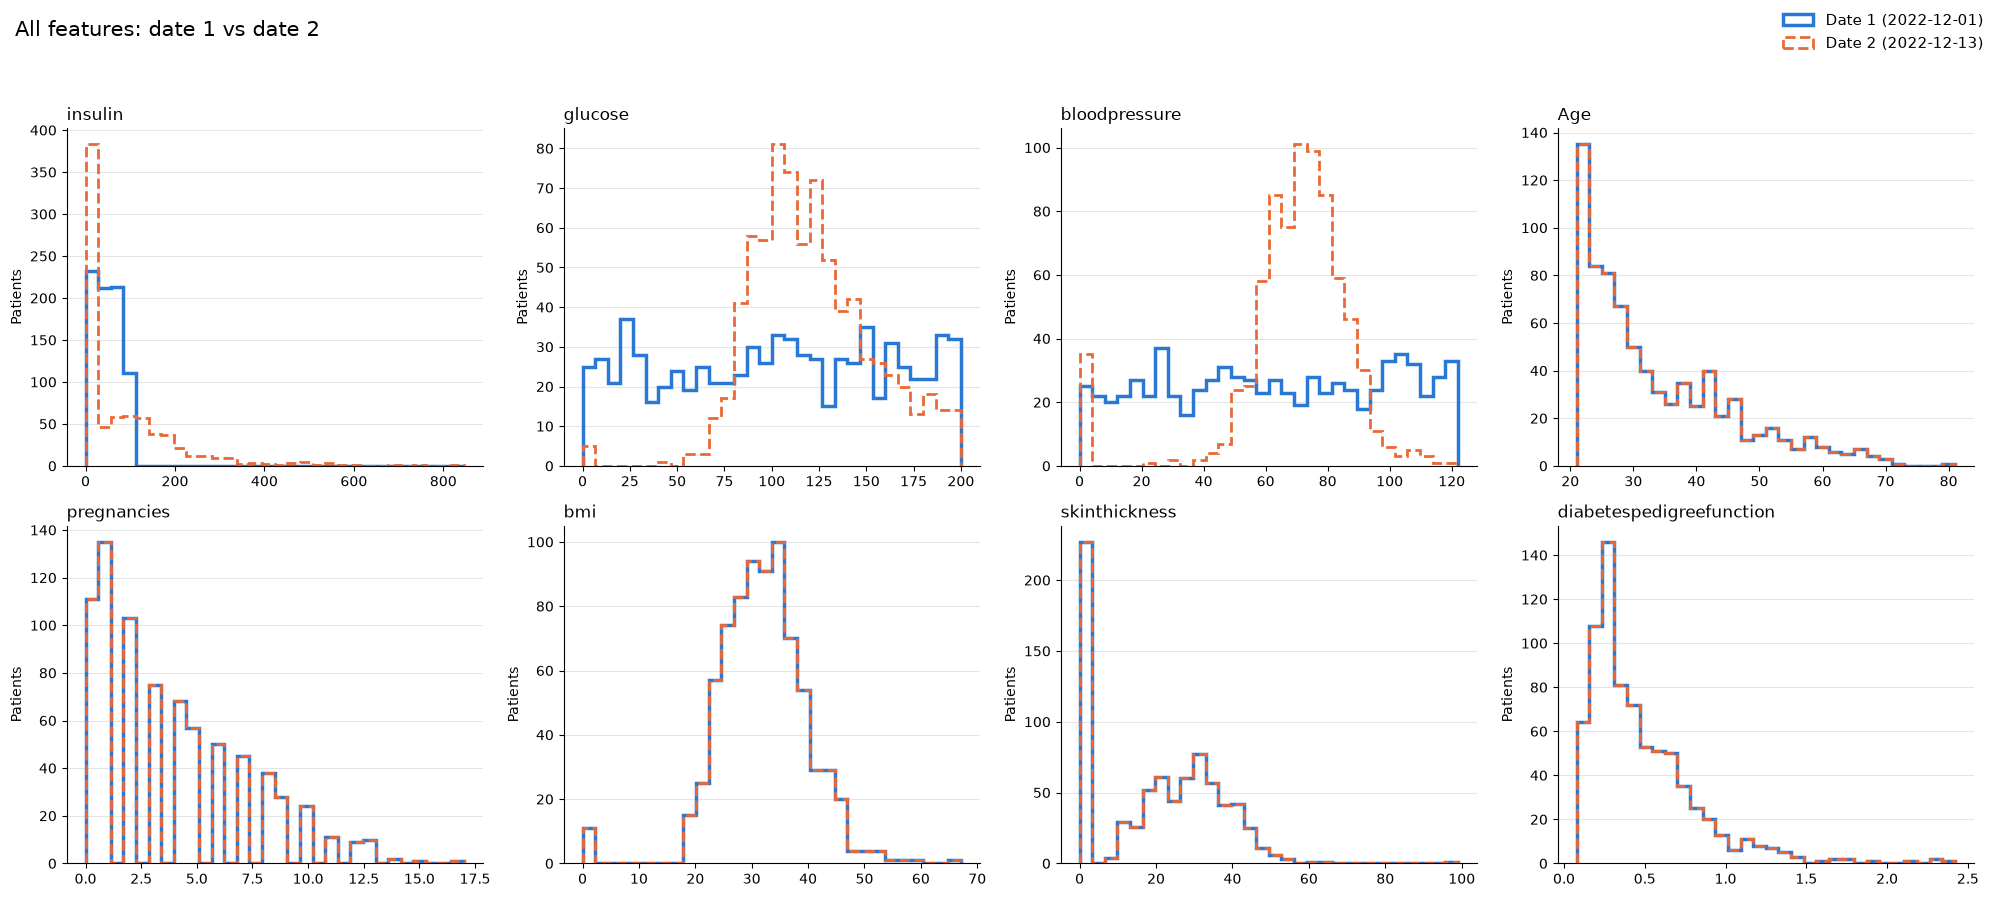

In [34]:
import matplotlib.pyplot as plt

all_features = ["insulin", "glucose", "bloodpressure",
                "Age", "pregnancies", "bmi", "skinthickness", "diabetespedigreefunction"]

def column_for_date(feature, date_number):
    # Blood metrics have _1/_2 columns; the other features have one column for both dates
    return f"{feature}_{date_number}" if feature in ("insulin", "glucose", "bloodpressure") else feature

fig, axes = plt.subplots(2, 4, figsize=(20, 9))

for ax, feature in zip(axes.flat, all_features):
    values_date1 = diabetes_combined[column_for_date(feature, 1)]
    values_date2 = diabetes_combined[column_for_date(feature, 2)]
    value_range = (min(values_date1.min(), values_date2.min()),
                   max(values_date1.max(), values_date2.max()))

    ax.hist(values_date1, bins=30, range=value_range, histtype="step", linewidth=2.5,
            color="#2a78d6", label="Date 1 (2022-12-01)")
    ax.hist(values_date2, bins=30, range=value_range, histtype="step", linewidth=2,
            linestyle="--", color="#eb6834", label="Date 2 (2022-12-13)")

    ax.set_title(feature, fontsize=12, loc="left")
    ax.set_ylabel("Patients")
    ax.grid(axis="y", color="#e5e5e5", linewidth=0.8)
    ax.set_axisbelow(True)
    ax.spines[["top", "right"]].set_visible(False)

handles, labels = axes.flat[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper right", frameon=False, fontsize=11)
fig.suptitle("All features: date 1 vs date 2", fontsize=15, x=0.01, ha="left")
fig.tight_layout(rect=(0, 0, 1, 0.94))
plt.show()

In [35]:
fig.savefig("data/all_features_date1_vs_date2.png", dpi=150, bbox_inches="tight")

,feature,date,mean (no diabetes),mean (diabetes),correlation
0,insulin,1,47.6,50.0,0.040
1,insulin,2,68.8,100.3,0.131
2,glucose,1,104.4,97.5,-0.057
3,glucose,2,110.0,141.3,0.467
4,bloodpressure,1,64.2,60.9,-0.044
5,bloodpressure,2,68.2,70.8,0.065


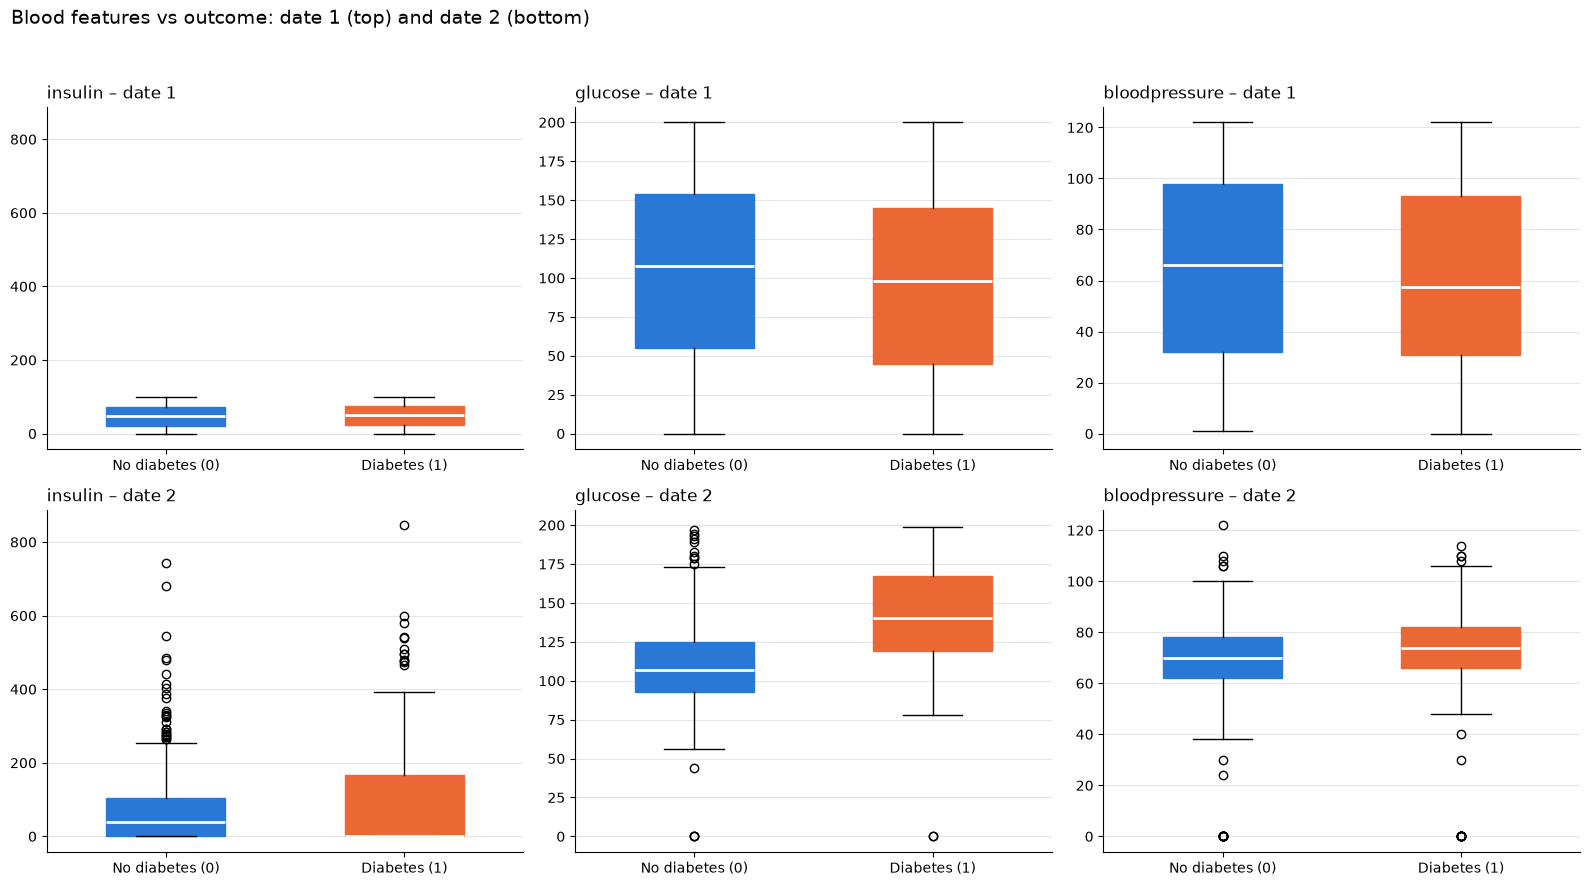

In [36]:
import matplotlib.pyplot as plt

blood_features = ["insulin", "glucose", "bloodpressure"]
outcome_colors = {0: "#2a78d6", 1: "#eb6834"}

# 1. Numbers: mean per outcome and correlation with outcome, for both dates
outcome_summary = []
for metric in blood_features:
    for date_number in (1, 2):
        col = f"{metric}_{date_number}"
        outcome_summary.append({
            "feature":            metric,
            "date":               date_number,
            "mean (no diabetes)": diabetes_combined.loc[diabetes_combined["outcome"] == 0, col].mean().round(1),
            "mean (diabetes)":    diabetes_combined.loc[diabetes_combined["outcome"] == 1, col].mean().round(1),
            "correlation":        round(diabetes_combined[col].corr(diabetes_combined["outcome"]), 3),
        })
display(pd.DataFrame(outcome_summary))

# 2. Plot: rows = dates, columns = features, boxes = outcome
fig, axes = plt.subplots(2, 3, figsize=(16, 9), sharey="col")
for row, date_number in enumerate((1, 2)):
    for col_idx, metric in enumerate(blood_features):
        ax = axes[row, col_idx]
        col = f"{metric}_{date_number}"
        groups = [diabetes_combined.loc[diabetes_combined["outcome"] == o, col] for o in (0, 1)]
        boxes = ax.boxplot(groups, patch_artist=True, widths=0.5,
                           medianprops={"color": "white", "linewidth": 2})
        for patch, o in zip(boxes["boxes"], (0, 1)):
            patch.set_facecolor(outcome_colors[o])
            patch.set_edgecolor(outcome_colors[o])
        ax.set_xticks([1, 2], ["No diabetes (0)", "Diabetes (1)"])
        ax.set_title(f"{metric} – date {date_number}", fontsize=12, loc="left")
        ax.grid(axis="y", color="#e5e5e5", linewidth=0.8)
        ax.set_axisbelow(True)
        ax.spines[["top", "right"]].set_visible(False)

fig.suptitle("Blood features vs outcome: date 1 (top) and date 2 (bottom)", fontsize=14, x=0.01, ha="left")
fig.tight_layout(rect=(0, 0, 1, 0.95))
fig.savefig("data/blood_features_vs_outcome.png", dpi=150, bbox_inches="tight")
plt.show()

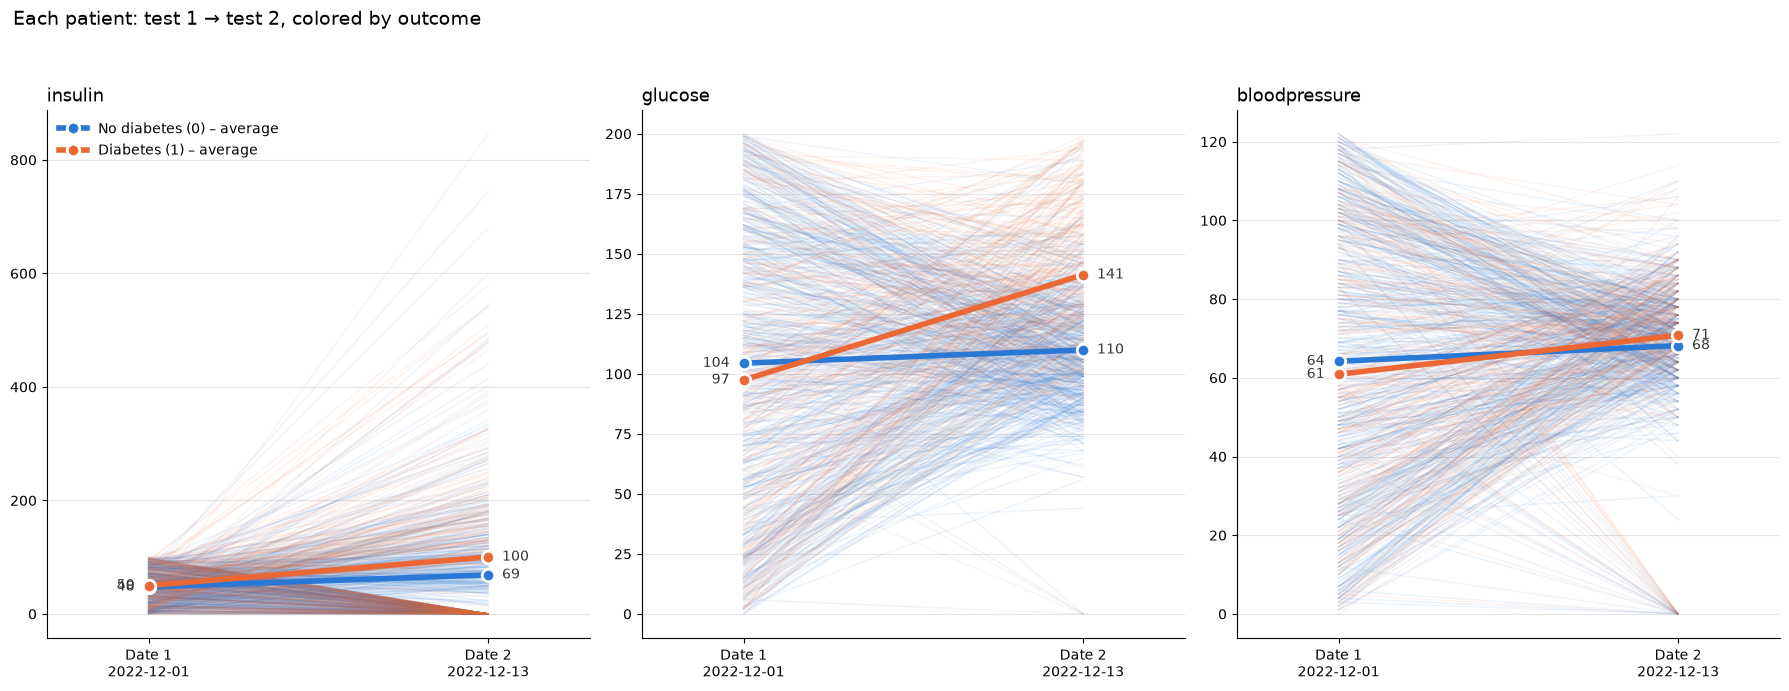

In [37]:
import matplotlib.pyplot as plt

blood_features = ["insulin", "glucose", "bloodpressure"]
outcome_colors = {0: "#2a78d6", 1: "#eb6834"}
outcome_labels = {0: "No diabetes (0)", 1: "Diabetes (1)"}

fig, axes = plt.subplots(1, 3, figsize=(18, 7))

for ax, metric in zip(axes, blood_features):
    # One thin line per patient: date 1 → date 2
    for outcome_value in (0, 1):
        group = diabetes_combined[diabetes_combined["outcome"] == outcome_value]
        for _, patient_row in group.iterrows():
            ax.plot([1, 2], [patient_row[f"{metric}_1"], patient_row[f"{metric}_2"]],
                    color=outcome_colors[outcome_value], alpha=0.08, linewidth=1)

    # Thick line: average patient of each group
    for outcome_value in (0, 1):
        group = diabetes_combined[diabetes_combined["outcome"] == outcome_value]
        mean_1, mean_2 = group[f"{metric}_1"].mean(), group[f"{metric}_2"].mean()
        ax.plot([1, 2], [mean_1, mean_2], color=outcome_colors[outcome_value], linewidth=4,
                marker="o", markersize=9, markeredgecolor="white", markeredgewidth=2,
                label=f"{outcome_labels[outcome_value]} – average")
        ax.annotate(f"{mean_2:.0f}", (2, mean_2), xytext=(10, 0), textcoords="offset points",
                    va="center", fontsize=10, color="#333")
        ax.annotate(f"{mean_1:.0f}", (1, mean_1), xytext=(-10, 0), textcoords="offset points",
                    va="center", ha="right", fontsize=10, color="#333")

    ax.set_xticks([1, 2], ["Date 1\n2022-12-01", "Date 2\n2022-12-13"])
    ax.set_xlim(0.7, 2.3)
    ax.set_title(metric, fontsize=13, loc="left")
    ax.grid(axis="y", color="#e5e5e5", linewidth=0.8)
    ax.set_axisbelow(True)
    ax.spines[["top", "right"]].set_visible(False)

axes[0].legend(frameon=False, loc="upper left")
fig.suptitle("Each patient: test 1 → test 2, colored by outcome", fontsize=14, x=0.01, ha="left")
fig.tight_layout(rect=(0, 0, 1, 0.94))
fig.savefig("data/patient_test1_to_test2_by_outcome.png", dpi=150, bbox_inches="tight")
plt.show()

In [38]:
changed = pd.DataFrame({
    metric: diabetes_combined[f"{metric}_1"] != diabetes_combined[f"{metric}_2"]
    for metric in ["insulin", "glucose", "bloodpressure"]
})

print("Changed per feature:")
print(changed.sum(), "\n")
print("At least one feature changed:", changed.any(axis=1).sum(), "of", len(changed))
print("All three features changed:  ", changed.all(axis=1).sum(), "of", len(changed))
print("Nothing changed at all:      ", (~changed.any(axis=1)).sum(), "of", len(changed))

Changed per feature:
insulin          763
glucose          764
bloodpressure    761
dtype: int64 

At least one feature changed: 768 of 768
All three features changed:   752 of 768
Nothing changed at all:       0 of 768


,patientid,glucose_change,glucose_abs_change,Age,pregnancies,bmi,skinthickness,diabetespedigreefunction,outcome
569,570,0,0,33,0,34.3,30,0.203,1
138,139,0,0,29,0,31.2,0,0.703,0
467,468,0,0,25,0,36.8,36,0.600,0
654,655,0,0,22,1,34.2,28,0.142,0
466,467,1,1,22,0,27.8,10,0.269,0
666,667,-1,1,70,4,32.5,18,0.235,1
499,500,-1,1,39,6,29.3,32,0.839,0
172,173,-1,1,25,2,28.9,23,0.773,0
295,296,-1,1,28,6,35.5,31,0.692,0
153,154,1,1,23,1,40.6,42,0.687,0


,patientid,glucose_change,glucose_abs_change,Age,pregnancies,bmi,skinthickness,diabetespedigreefunction,outcome
332,333,159,159,41,1,43.3,0,0.282,1
206,207,162,162,57,8,37.5,29,0.605,1
40,41,163,163,26,3,34.0,25,0.271,0
370,371,164,164,25,3,38.4,48,2.137,1
646,647,165,165,33,1,23.4,17,0.447,1
56,57,166,166,41,7,37.7,39,0.254,1
455,456,173,173,38,14,33.6,30,0.212,1
45,46,174,174,25,0,42.0,39,1.893,1
399,400,178,178,25,3,34.9,31,0.241,1
606,607,179,179,22,1,40.0,42,1.258,1


Correlation between SIZE of change and other features (close to 0 = no relation):


,insulin,glucose,bloodpressure
Age,0.041,0.063,0.015
pregnancies,-0.016,0.037,0.041
bmi,0.178,0.020,-0.059
skinthickness,0.260,0.057,-0.091
diabetespedigreefunction,0.139,0.042,-0.010
outcome,0.163,0.166,0.071



insulin: average of other features per change group


,Age,pregnancies,bmi,skinthickness,diabetespedigreefunction,outcome
insulin_change_group,,,,,,
Q1 lowest,31.79,3.76,30.77,19.20,0.44,0.26
Q2,32.97,3.74,31.27,16.54,0.46,0.30
Q3,35.14,4.02,31.46,17.40,0.43,0.36
Q4 highest,33.02,3.86,34.59,29.44,0.56,0.48



glucose: average of other features per change group


,Age,pregnancies,bmi,skinthickness,diabetespedigreefunction,outcome
glucose_change_group,,,,,,
Q1 lowest,33.03,3.72,32.71,20.99,0.47,0.33
Q2,33.25,3.88,32.02,18.36,0.47,0.31
Q3,32.29,3.91,30.45,20.53,0.45,0.28
Q4 highest,34.41,3.87,32.79,22.29,0.50,0.48



bloodpressure: average of other features per change group


,Age,pregnancies,bmi,skinthickness,diabetespedigreefunction,outcome
bloodpressure_change_group,,,,,,
Q1 lowest,33.84,4.01,31.88,21.59,0.45,0.33
Q2,32.27,3.37,33.00,21.99,0.50,0.34
Q3,32.97,4.05,31.70,19.40,0.47,0.35
Q4 highest,33.89,3.95,31.37,19.09,0.46,0.39


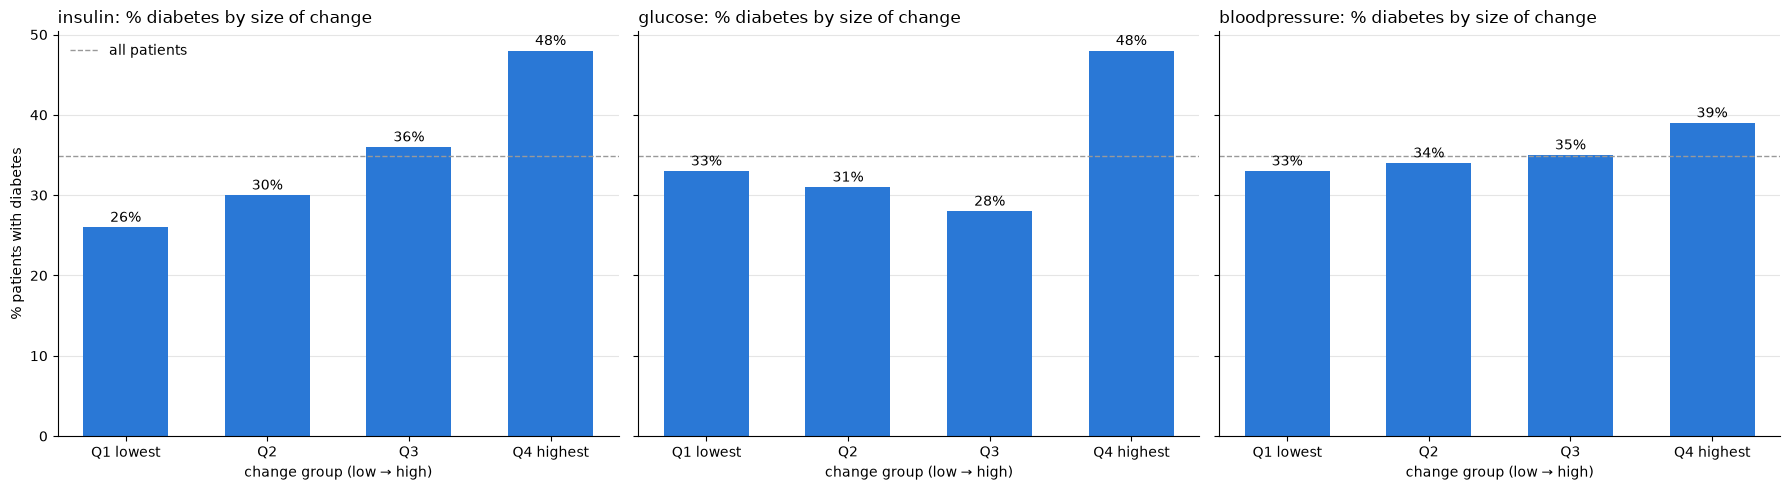

In [39]:
import matplotlib.pyplot as plt

blood_features = ["insulin", "glucose", "bloodpressure"]
other_features = ["Age", "pregnancies", "bmi", "skinthickness", "diabetespedigreefunction", "outcome"]

# 1. Change per patient: signed (up/down) and absolute (size)
patient_changes = diabetes_combined[["patientid"] + other_features].copy()
for metric in blood_features:
    patient_changes[f"{metric}_change"] = diabetes_combined[f"{metric}_2"] - diabetes_combined[f"{metric}_1"]
    patient_changes[f"{metric}_abs_change"] = patient_changes[f"{metric}_change"].abs()

# 2. Patients ordered from low to high glucose change
display(patient_changes.sort_values("glucose_abs_change")
        [["patientid", "glucose_change", "glucose_abs_change"] + other_features].head(10))
display(patient_changes.sort_values("glucose_abs_change")
        [["patientid", "glucose_change", "glucose_abs_change"] + other_features].tail(10))

# 3. Correlation: size of change vs other features
change_corr = pd.DataFrame({
    metric: [patient_changes[f"{metric}_abs_change"].corr(patient_changes[feature]) for feature in other_features]
    for metric in blood_features
}, index=other_features).round(3)
print("Correlation between SIZE of change and other features (close to 0 = no relation):")
display(change_corr)

# 4. Patients in 4 groups from low to high change: average of other features per group
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)
for ax, metric in zip(axes, blood_features):
    patient_changes[f"{metric}_change_group"] = pd.qcut(patient_changes[f"{metric}_abs_change"], 4,
                                                        labels=["Q1 lowest", "Q2", "Q3", "Q4 highest"])
    group_means = patient_changes.groupby(f"{metric}_change_group", observed=True)[other_features].mean().round(2)
    print(f"\n{metric}: average of other features per change group")
    display(group_means)

    diabetes_rate = group_means["outcome"] * 100
    ax.bar(diabetes_rate.index.astype(str), diabetes_rate.values, color="#2a78d6", width=0.6)
    for x, y in enumerate(diabetes_rate.values):
        ax.annotate(f"{y:.0f}%", (x, y), xytext=(0, 4), textcoords="offset points", ha="center", fontsize=10)
    ax.axhline(diabetes_combined["outcome"].mean() * 100, color="#999", linestyle="--", linewidth=1,
               label="all patients")
    ax.set_title(f"{metric}: % diabetes by size of change", fontsize=12, loc="left")
    ax.set_xlabel("change group (low → high)")
    ax.grid(axis="y", color="#e5e5e5", linewidth=0.8)
    ax.set_axisbelow(True)
    ax.spines[["top", "right"]].set_visible(False)

axes[0].set_ylabel("% patients with diabetes")
axes[0].legend(frameon=False)
fig.tight_layout()
fig.savefig("data/change_groups_vs_diabetes.png", dpi=150, bbox_inches="tight")
plt.show()

In [40]:
patient_changes.sort_values("glucose_abs_change", ascending=False).head(10)

,patientid,Age,pregnancies,bmi,skinthickness,diabetespedigreefunction,outcome,insulin_change,insulin_abs_change,glucose_change,glucose_abs_change,bloodpressure_change,bloodpressure_abs_change,insulin_change_group,glucose_change_group,bloodpressure_change_group
606,607,22,1,40.0,42,1.258,1,224,224,179,179,12,12,Q4 highest,Q4 highest,Q1 lowest
399,400,25,3,34.9,31,0.241,1,-98,98,178,178,66,66,Q4 highest,Q4 highest,Q4 highest
45,46,25,0,42.0,39,1.893,1,-75,75,174,174,-27,27,Q3,Q4 highest,Q2
455,456,38,14,33.6,30,0.212,1,-96,96,173,173,2,2,Q4 highest,Q4 highest,Q1 lowest
56,57,41,7,37.7,39,0.254,1,221,221,166,166,55,55,Q4 highest,Q4 highest,Q4 highest
646,647,33,1,23.4,17,0.447,1,114,114,165,165,71,71,Q4 highest,Q4 highest,Q4 highest
370,371,25,3,38.4,48,2.137,1,429,429,164,164,58,58,Q4 highest,Q4 highest,Q4 highest
40,41,26,3,34.0,25,0.271,0,-3,3,163,163,-58,58,Q1 lowest,Q4 highest,Q4 highest
206,207,57,8,37.5,29,0.605,1,249,249,162,162,-8,8,Q4 highest,Q4 highest,Q1 lowest
662,663,43,8,37.6,46,0.165,1,220,220,159,159,9,9,Q4 highest,Q4 highest,Q1 lowest


In [41]:
cols = ["insulin_change", "glucose_change", "bloodpressure_change"]

print(patient_changes[cols].corr(method="pearson").round(2))   # linear relationship
print(patient_changes[cols].corr(method="spearman").round(2))  # rank-based, less affected by outliers

                      insulin_change  glucose_change  bloodpressure_change
insulin_change                  1.00            0.18                  0.12
glucose_change                  0.18            1.00                  0.07
bloodpressure_change            0.12            0.07                  1.00
                      insulin_change  glucose_change  bloodpressure_change
insulin_change                  1.00            0.09                  0.07
glucose_change                  0.09            1.00                  0.08
bloodpressure_change            0.07            0.08                  1.00


In [42]:
from scipy.stats import spearmanr
from itertools import combinations

for a, b in combinations(cols, 2):
    r, p = spearmanr(patient_changes[a], patient_changes[b], nan_policy="omit")
    print(f"{a} vs {b}: r={r:.2f}, p={p:.4f}")

insulin_change vs glucose_change: r=0.09, p=0.0088
insulin_change vs bloodpressure_change: r=0.07, p=0.0672
glucose_change vs bloodpressure_change: r=0.08, p=0.0336


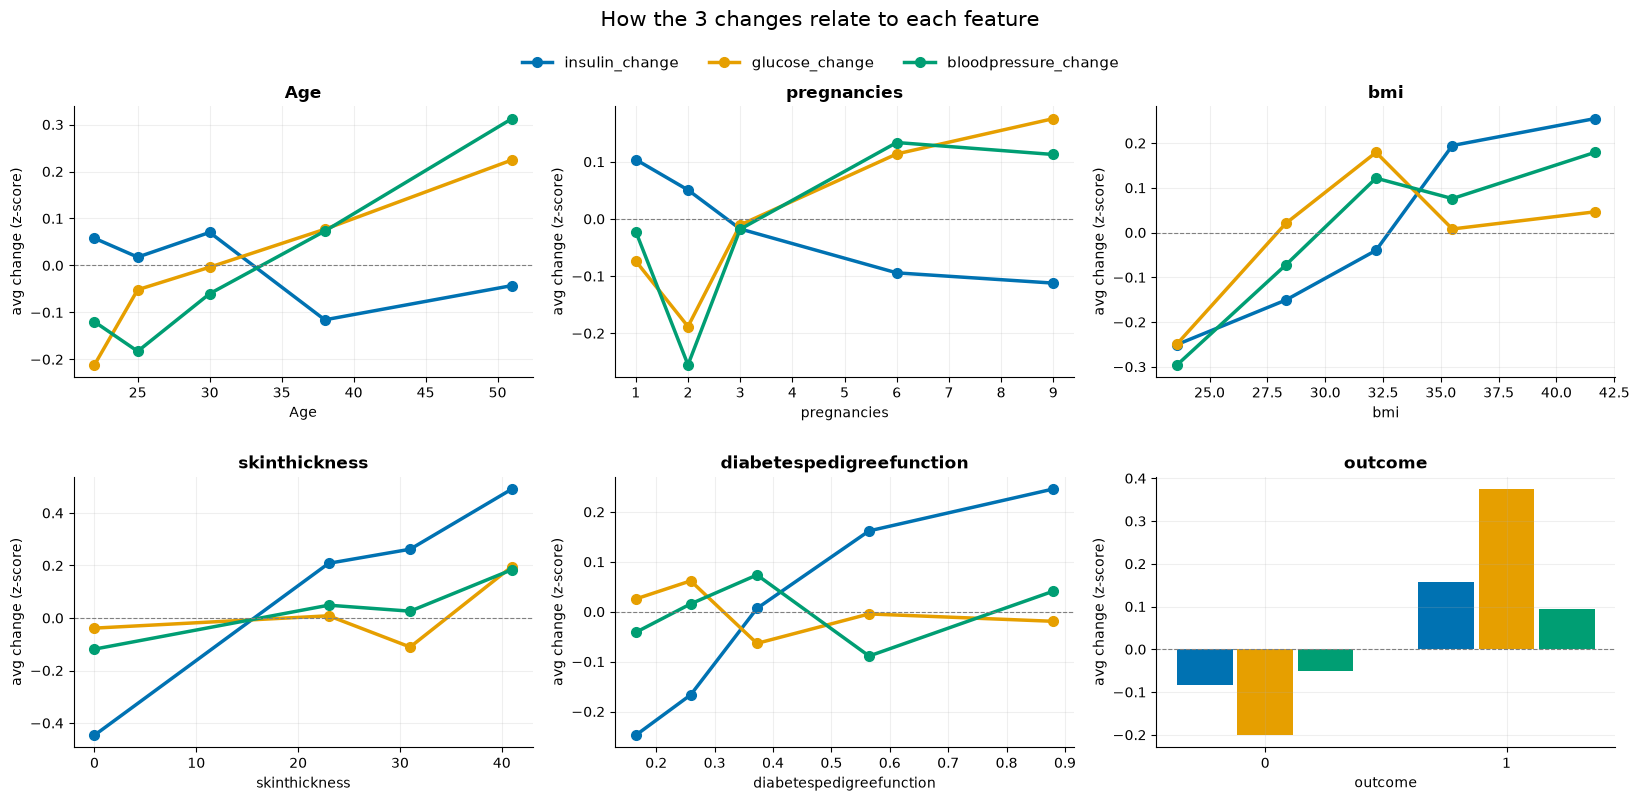

In [46]:
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

rel2_change_cols = ["insulin_change", "glucose_change", "bloodpressure_change"]
rel2_colors = {"insulin_change": "#0072B2", "glucose_change": "#E69F00", "bloodpressure_change": "#009E73"}

rel2_feature_cols = [
    c for c in patient_changes.select_dtypes("number").columns
    if "change" not in c.lower() and "id" not in c.lower() and "date" not in c.lower()
]

# put all 3 changes on the same scale (z-score)
rel2_z = patient_changes[rel2_change_cols].apply(lambda s: (s - s.mean()) / s.std())

rel2_ncols = 3
rel2_nrows = math.ceil(len(rel2_feature_cols) / rel2_ncols)
rel2_fig, rel2_axes = plt.subplots(rel2_nrows, rel2_ncols, figsize=(5.5 * rel2_ncols, 4 * rel2_nrows), squeeze=False)
rel2_axes = rel2_axes.flatten()

for rel2_ax, rel2_feat in zip(rel2_axes, rel2_feature_cols):
    rel2_x = patient_changes[rel2_feat]

    if rel2_x.nunique() <= 2:                       # binary feature, e.g. outcome -> grouped bars
        rel2_means = rel2_z.groupby(rel2_x).mean()
        rel2_pos = np.arange(len(rel2_means.index))
        for i, rel2_c in enumerate(rel2_change_cols):
            rel2_ax.bar(rel2_pos + (i - 1) * 0.25, rel2_means[rel2_c], width=0.23,
                        color=rel2_colors[rel2_c], label=rel2_c)
        rel2_ax.set_xticks(rel2_pos)
        rel2_ax.set_xticklabels(rel2_means.index)
    else:                                           # numeric feature -> mean change per quintile
        rel2_bins = pd.qcut(rel2_x, q=5, duplicates="drop")
        rel2_means = rel2_z.groupby(rel2_bins, observed=True).mean()
        rel2_mid = rel2_x.groupby(rel2_bins, observed=True).median()
        for rel2_c in rel2_change_cols:
            rel2_ax.plot(rel2_mid, rel2_means[rel2_c], marker="o", lw=2.5, ms=7,
                         color=rel2_colors[rel2_c], label=rel2_c)

    rel2_ax.axhline(0, color="gray", lw=0.8, ls="--")
    rel2_ax.set_title(rel2_feat, fontsize=12, fontweight="bold")
    rel2_ax.set_xlabel(rel2_feat)
    rel2_ax.set_ylabel("avg change (z-score)")
    rel2_ax.grid(alpha=0.2)
    rel2_ax.spines[["top", "right"]].set_visible(False)

for rel2_ax in rel2_axes[len(rel2_feature_cols):]:
    rel2_ax.set_visible(False)    

rel2_handles, rel2_labels = rel2_axes[0].get_legend_handles_labels()
rel2_fig.tight_layout(rect=[0, 0, 1, 0.92], h_pad=2.5)    # keep the top 8% free for title + legend; more space between rows
rel2_fig.suptitle("How the 3 changes relate to each feature", fontsize=15, y=0.995)
rel2_fig.legend(rel2_handles, rel2_labels, loc="upper center", bbox_to_anchor=(0.5, 0.955),
                ncol=3, fontsize=11, frameon=False)
rel2_fig.savefig("changes_vs_features.png", dpi=300, bbox_inches="tight")
plt.show()

What the plot tells us
Outcome (diabetes yes/no): this shows the clearest difference. Patients with diabetes (1) had a larger change than average on all three metrics, especially glucose (+0.38). Patients without diabetes (0) were below average on all three. Earlier I wrote that patients with diabetes "increased" on all three metrics. That was too strong: the plot only shows they changed more than average, not that their values actually went up.
BMI: all three lines rise. The higher the BMI, the larger the change on every metric. This is the only feature where all three changes clearly move together.
Age and pregnancies: glucose and blood pressure rise with both, but insulin goes the opposite way. Older women have usually had more pregnancies, so this is likely one and the same effect showing up in two panels.
Skin thickness and diabetes pedigree: mainly the insulin line rises. Glucose and blood pressure stay close to 0, so these two features seem linked only to insulin change.
One caution: in the Pima dataset, a value of 0 for skin thickness or insulin usually means the measurement is missing. The very low blue point at skin thickness = 0 is probably caused by that, and not by a real effect.

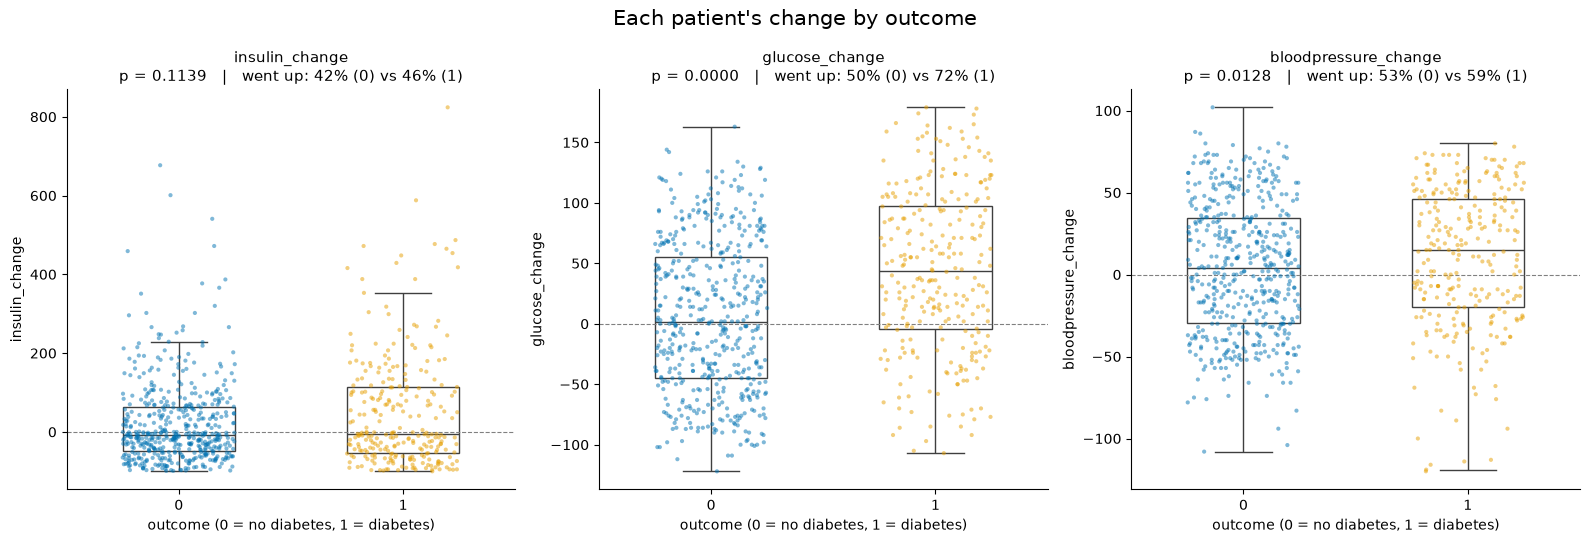

In [47]:
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import mannwhitneyu

rel4_change_cols = ["insulin_change", "glucose_change", "bloodpressure_change"]
rel4_fig, rel4_axes = plt.subplots(1, 3, figsize=(16, 5.5))

for rel4_ax, rel4_c in zip(rel4_axes, rel4_change_cols):
    rel4_data = patient_changes[[rel4_c, "outcome"]].dropna()

    sns.boxplot(data=rel4_data, x="outcome", y=rel4_c, ax=rel4_ax, width=0.5,
                showfliers=False, boxprops={"facecolor": "none"})
    sns.stripplot(data=rel4_data, x="outcome", y=rel4_c, ax=rel4_ax, hue="outcome",
                  palette={0: "#0072B2", 1: "#E69F00"}, size=3, alpha=0.5, jitter=0.25, legend=False)

    rel4_g0 = rel4_data.loc[rel4_data["outcome"] == 0, rel4_c]
    rel4_g1 = rel4_data.loc[rel4_data["outcome"] == 1, rel4_c]
    rel4_p = mannwhitneyu(rel4_g0, rel4_g1).pvalue
    rel4_up0 = (rel4_g0 > 0).mean() * 100
    rel4_up1 = (rel4_g1 > 0).mean() * 100

    rel4_ax.axhline(0, color="gray", lw=0.8, ls="--")          # here 0 really means "no change"
    rel4_ax.set_title(f"{rel4_c}\np = {rel4_p:.4f}   |   went up: {rel4_up0:.0f}% (0) vs {rel4_up1:.0f}% (1)",
                      fontsize=11)
    rel4_ax.set_xlabel("outcome (0 = no diabetes, 1 = diabetes)")
    rel4_ax.spines[["top", "right"]].set_visible(False)

rel4_fig.suptitle("Each patient's change by outcome", fontsize=15)
plt.tight_layout()
plt.show()

In [48]:
rel4_fig.savefig("changes_by_outcome.png", dpi=300, bbox_inches="tight")
print("Plot saved as changes_by_outcome.png")

Plot saved as changes_by_outcome.png


In [49]:
rel7_rows = []
for rel7_c in ["insulin_change", "glucose_change", "bloodpressure_change"]:
    for rel7_label, rel7_mask in [("went up", patient_changes[rel7_c] > 0),
                                  ("went down/same", patient_changes[rel7_c] <= 0)]:
        rel7_group = patient_changes.loc[rel7_mask, "outcome"]
        rel7_rows.append({
            "change": rel7_c,
            "direction": rel7_label,
            "patients": len(rel7_group),
            "% diabetes (1)": round((rel7_group == 1).mean() * 100, 1),
            "% no diabetes (0)": round((rel7_group == 0).mean() * 100, 1),
        })

rel7_table = pd.DataFrame(rel7_rows).set_index(["change", "direction"])
print(f"All patients: {patient_changes['outcome'].mean() * 100:.1f}% have diabetes")
display(rel7_table)

All patients: 34.9% have diabetes


patients  % diabetes (1)  \
change               direction                                  
insulin_change       went up              333            36.9   
                     went down/same       435            33.3   
glucose_change       went up              446            43.5   
                     went down/same       322            23.0   
bloodpressure_change went up              421            37.3   
                     went down/same       347            32.0   

                                     % no diabetes (0)  
change               direction                          
insulin_change       went up                      63.1  
                     went down/same               66.7  
glucose_change       went up                      56.5  
                     went down/same               77.0  
bloodpressure_change went up                      62.7  
                     went down/same               68.0

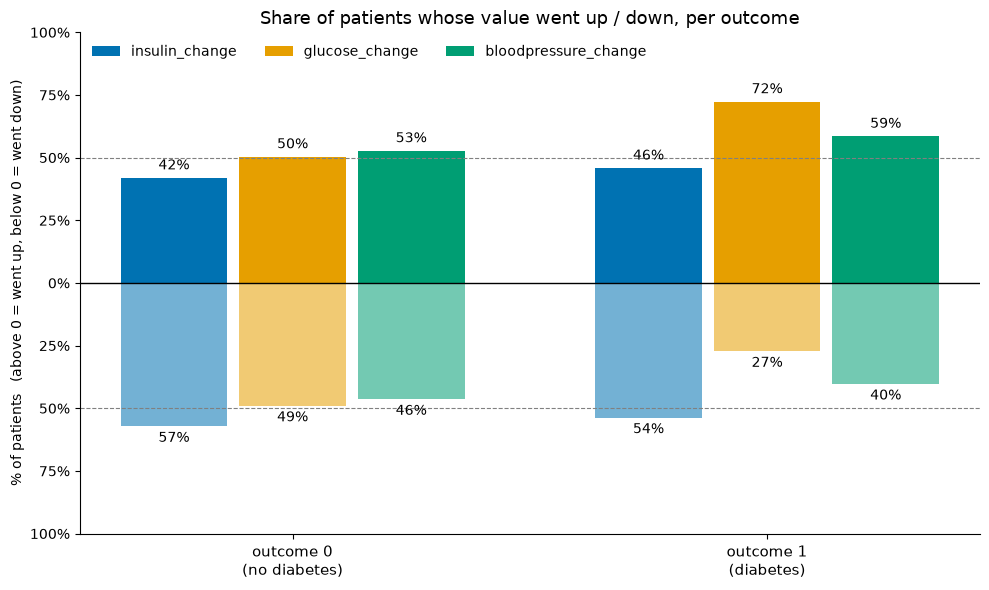

In [51]:
rel10_change_cols = ["insulin_change", "glucose_change", "bloodpressure_change"]
rel10_colors = {"insulin_change": "#0072B2", "glucose_change": "#E69F00", "bloodpressure_change": "#009E73"}

rel10_fig, rel10_ax = plt.subplots(figsize=(10, 6))
rel10_width = 0.25

for rel10_x, rel10_out in enumerate([0, 1]):
    rel10_grp = patient_changes[patient_changes["outcome"] == rel10_out]
    for i, rel10_c in enumerate(rel10_change_cols):
        rel10_pos = rel10_x + (i - 1) * rel10_width
        rel10_up = (rel10_grp[rel10_c] > 0).mean() * 100
        rel10_down = (rel10_grp[rel10_c] < 0).mean() * 100

        rel10_ax.bar(rel10_pos, rel10_up, width=rel10_width * 0.9, color=rel10_colors[rel10_c],
                     label=rel10_c if rel10_x == 0 else None)
        rel10_ax.bar(rel10_pos, -rel10_down, width=rel10_width * 0.9, color=rel10_colors[rel10_c], alpha=0.55)

        rel10_ax.text(rel10_pos, rel10_up + 2, f"{rel10_up:.0f}%", ha="center", va="bottom", fontsize=10)
        rel10_ax.text(rel10_pos, -rel10_down - 2, f"{rel10_down:.0f}%", ha="center", va="top", fontsize=10)

rel10_ax.set_ylim(-100, 100)                           # 0 exactly in the middle
rel10_ax.set_yticks(range(-100, 101, 25))
rel10_ax.set_yticklabels([f"{abs(t)}%" for t in range(-100, 101, 25)])
rel10_ax.axhline(0, color="black", lw=1)
rel10_ax.axhline(50, color="gray", lw=0.8, ls="--")    # 50% reference line
rel10_ax.axhline(-50, color="gray", lw=0.8, ls="--")
rel10_ax.set_xticks([0, 1])
rel10_ax.set_xticklabels(["outcome 0\n(no diabetes)", "outcome 1\n(diabetes)"], fontsize=11)
rel10_ax.set_ylabel("% of patients   (above 0 = went up, below 0 = went down)")
rel10_ax.set_title("Share of patients whose value went up / down, per outcome", fontsize=13)
rel10_ax.legend(frameon=False, loc="upper left", ncol=3)
rel10_ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

In [52]:
rel10_fig.savefig("updown_percent_by_outcome.png", dpi=300, bbox_inches="tight")
print("Plot saved as updown_percent_by_outcome.png")

Plot saved as updown_percent_by_outcome.png


In [53]:
rel11_n = ((patient_changes["outcome"] == 1) & (patient_changes["glucose_change"] > 0)).sum()
print(f"Patients with diabetes whose glucose went up: {rel11_n} of {(patient_changes['outcome'] == 1).sum()}")

Patients with diabetes whose glucose went up: 194 of 268


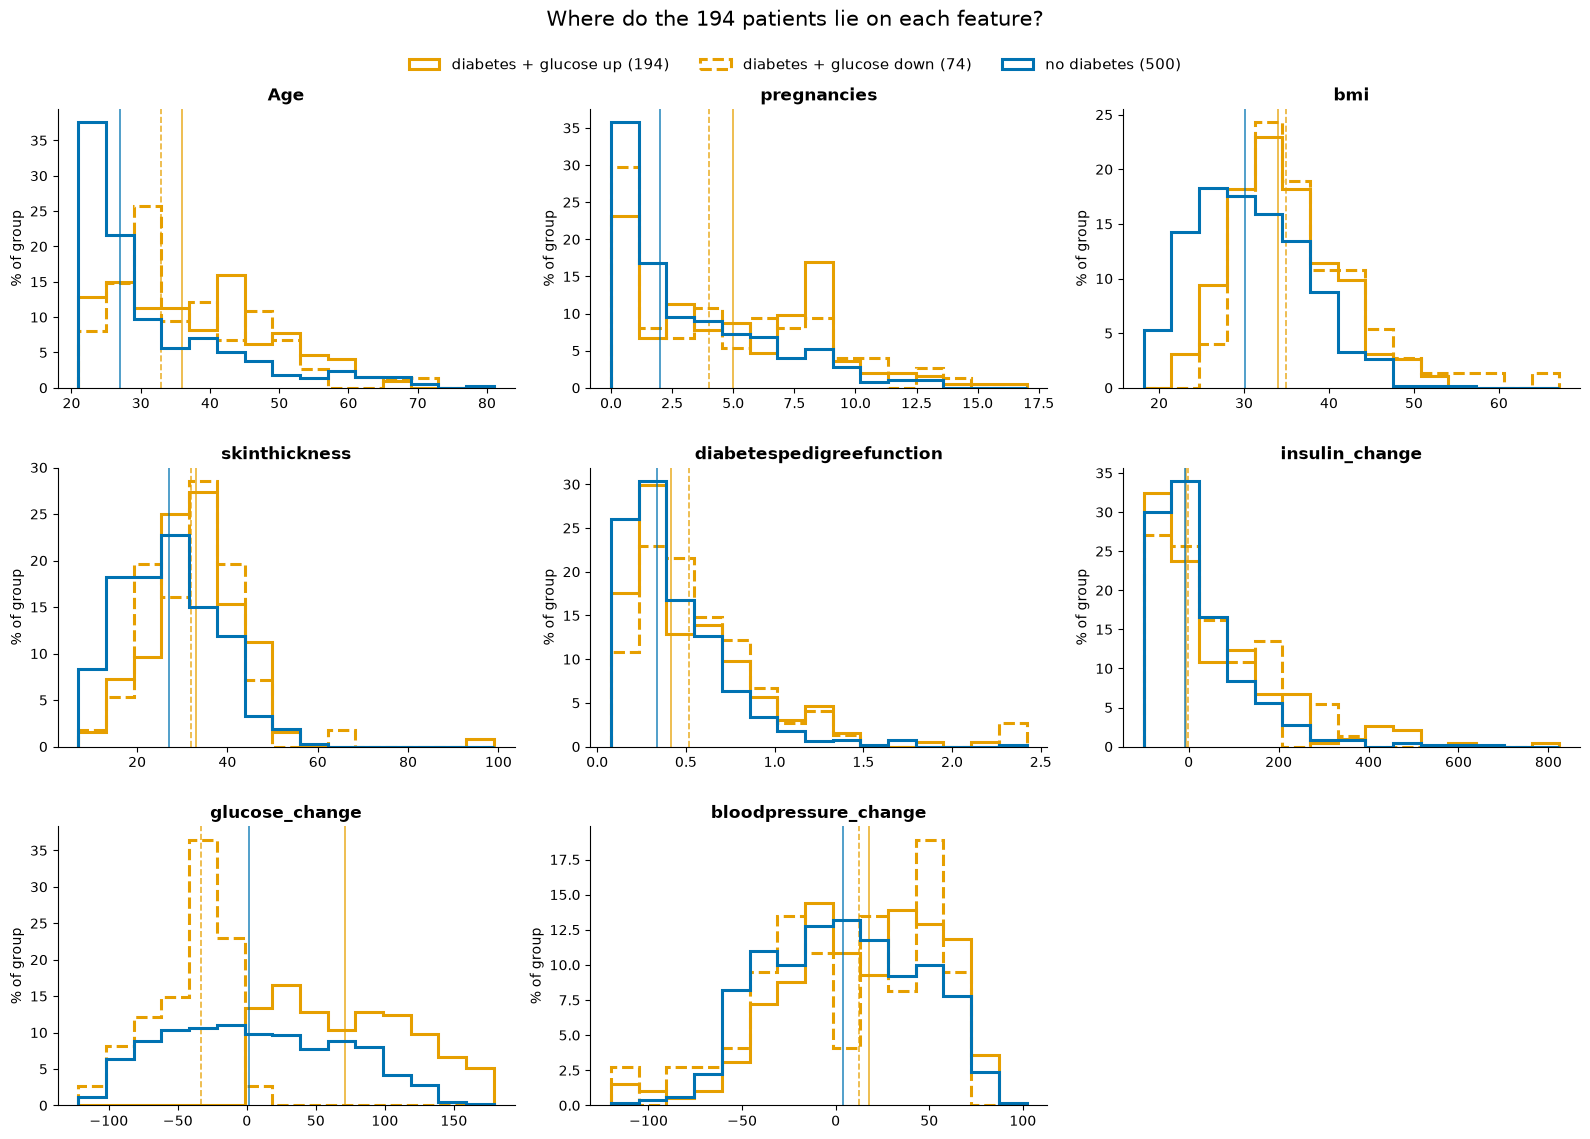

In [55]:
import math
import matplotlib.pyplot as plt

rel16_df = patient_changes.copy()
for rel16_col in rel16_df.columns:          # 0 = missing in these Pima columns
    if any(k in rel16_col.lower() for k in ["glucose", "bloodpressure", "skinthickness", "insulin", "bmi"]) \
            and "change" not in rel16_col.lower():
        rel16_df[rel16_col] = rel16_df[rel16_col].replace(0, np.nan)

rel16_groups = {
    "diabetes + glucose up (194)":   ((rel16_df["outcome"] == 1) & (rel16_df["glucose_change"] > 0),  "#E69F00", "-"),
    "diabetes + glucose down (74)":  ((rel16_df["outcome"] == 1) & (rel16_df["glucose_change"] <= 0), "#E69F00", "--"),
    "no diabetes (500)":             ((rel16_df["outcome"] == 0),                                      "#0072B2", "-"),
}

rel16_features = [c for c in rel16_df.select_dtypes("number").columns
                  if c != "outcome" and "id" not in c.lower() and "date" not in c.lower()
                  and "abs_change" not in c.lower()]

rel16_ncols = 3
rel16_nrows = math.ceil(len(rel16_features) / rel16_ncols)
rel16_fig, rel16_axes = plt.subplots(rel16_nrows, rel16_ncols, figsize=(16, 3.8 * rel16_nrows), squeeze=False)
rel16_axes = rel16_axes.flatten()

for rel16_ax, rel16_f in zip(rel16_axes, rel16_features):
    rel16_bins = np.histogram_bin_edges(rel16_df[rel16_f].dropna(), bins=15)
    for rel16_name, (rel16_mask, rel16_color, rel16_ls) in rel16_groups.items():
        rel16_vals = rel16_df.loc[rel16_mask, rel16_f].dropna()
        rel16_weights = np.ones(len(rel16_vals)) / len(rel16_vals) * 100      # % of the group
        rel16_ax.hist(rel16_vals, bins=rel16_bins, weights=rel16_weights, histtype="step",
                      lw=2.2, color=rel16_color, ls=rel16_ls, label=rel16_name)
        rel16_ax.axvline(rel16_vals.median(), color=rel16_color, ls=rel16_ls, lw=1.2, alpha=0.8)
    rel16_ax.set_title(rel16_f, fontsize=12, fontweight="bold")
    rel16_ax.set_ylabel("% of group")
    rel16_ax.spines[["top", "right"]].set_visible(False)

for rel16_ax in rel16_axes[len(rel16_features):]:
    rel16_ax.set_visible(False)

rel16_handles, rel16_labels = rel16_axes[0].get_legend_handles_labels()
rel16_fig.tight_layout(rect=[0, 0, 1, 0.94], h_pad=2.5)
rel16_fig.suptitle("Where do the 194 patients lie on each feature?", fontsize=15, y=0.995)
rel16_fig.legend(rel16_handles, rel16_labels, loc="upper center", bbox_to_anchor=(0.5, 0.965),
                 ncol=3, fontsize=11, frameon=False)
plt.show()